# Experiment 07 — Feature Selection and Feature Extraction Techniques

## Aim
To implement and understand feature selection and feature extraction techniques for dimensionality reduction and improving model performance in Machine Learning.

## Dataset
- **Name:** Iris Species
- **File:** `Iris.csv`
- **Source:** https://www.kaggle.com/uciml/iris/data

## Theory

### Feature Selection
Involves choosing important features without changing them. Reduces overfitting, improves accuracy, and reduces training time.

**Methods:**
- **Filter** (e.g., Chi-Square test, correlation)
- **Wrapper** (e.g., Recursive Feature Elimination — RFE)
- **Embedded** (e.g., Lasso regularization)

### Feature Extraction
Creates new features by transforming existing features.

**Principal Component Analysis (PCA):**
- Converts correlated features into principal components.
- Retains maximum variance with fewer dimensions.

## Procedure / Implementation

### Step 1 — Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

### Step 2 — Load the dataset

In [2]:
df = pd.read_csv('Iris.csv')
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']
print(X.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


### Step 3 — Feature Selection using Chi-Square

In [3]:
selector = SelectKBest(chi2, k=2)
selector.fit(X, y)
print('Chi-Square Scores:', selector.scores_)
print('Selected feature indices:', selector.get_support(indices=True))
print('Selected features:', X.columns[selector.get_support()].tolist())

Chi-Square Scores: [ 10.81782088   3.59449902 116.16984746  67.24482759]
Selected feature indices: [2 3]
Selected features: ['PetalLengthCm', 'PetalWidthCm']


### Step 4 — Feature Selection using RFE

In [4]:
rfe = RFE(LogisticRegression(max_iter=200), n_features_to_select=2)
rfe.fit(X, y)
print('RFE Support:', rfe.support_)
print('Selected features:', X.columns[rfe.support_].tolist())
print('Feature Ranking:', rfe.ranking_)

RFE Support: [False False  True  True]
Selected features: ['PetalLengthCm', 'PetalWidthCm']
Feature Ranking: [3 2 1 1]


### Step 5 — Feature Extraction using PCA

Explained variance ratio: [0.92461621 0.05301557]
Total variance retained: 0.9776317750248013


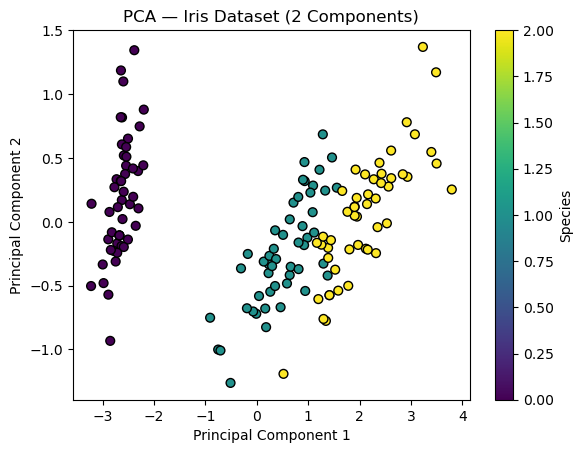

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total variance retained:', sum(pca.explained_variance_ratio_))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.Categorical(y).codes, cmap='viridis', edgecolors='k', s=40)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA — Iris Dataset (2 Components)')
plt.colorbar(label='Species')
plt.show()

## Output / Observations
- Chi-Square selected the two features with the strongest relation to the class labels.
- RFE removed less useful features until two remain.
- PCA created two new components while retaining most of the variance.
- The PCA scatter plot shows clear cluster separation among the three species.

## Result / Conclusion
Successfully implemented and analyzed feature selection and feature extraction techniques. Observed how reduced features still preserve important information for modeling.

Feature selection and extraction are essential steps in machine learning preprocessing. By selecting only the most relevant features (Chi-Square, RFE) or reducing dimensionality through PCA, we improve model efficiency, reduce overfitting, and maintain interpretability. PCA effectively visualizes high-dimensional data in lower dimensions while preserving maximum variance.

**CO Achieved:** CO4
- Apply KNN algorithm for classification and assess outcomes.

**POs Achieved:**
- PO1: Use distance metrics and algorithms for problem-solving.
- PO2: Analyze impact of K-value on model performance.
- PO3: Design classification systems using KNN for real-world datasets.
- PO4: Validate model results experimentally.
- PO5: Utilize modern ML libraries for KNN implementation.

**PSO Achieved:**
- PSO1: Apply KNN to AI/ML-based classification problems.
- PSO2: Integrate KNN into scalable real-time analytics pipelines.